In [1]:
import torch.nn as nn
import torchvision.models as models
from pathlib import Path
import torch

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)
state_dict = torch.load(
    Path("../models/resnet18_mnist_trained.pth"), map_location=device
)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
from torchvision.transforms import transforms
from torchvision import datasets
from torch.utils.data import DataLoader

In [4]:
transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

test_data = datasets.MNIST(
    root="../data", download=False, train=False, transform=transform
)

test_loader = DataLoader(
    test_data, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
)

## integrated gradients

In [5]:
# wyciągam obrazek i etykiete z test_loadera
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Bierzemy pierwszy obrazek z batcha
input_img = images[0].unsqueeze(0).to(device)
target_label = labels[0].item()

input_img.requires_grad = True

model.eval()
output = model(input_img)
pred_label = output.max(1, keepdim=True)[1].item()

print(f"Prawdziwa etykieta: {target_label} | Predykcja: {pred_label}")

Prawdziwa etykieta: 7 | Predykcja: 7


In [6]:
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz
import numpy as np

In [7]:
ig = IntegratedGradients(model)
model.eval()
output = model(input_img)
pred_label = output.max(1, keepdim=True)[1].item()
print(f"Prawdziwa etykieta: {target_label} | Model widzi: {pred_label}")

Prawdziwa etykieta: 7 | Model widzi: 7


In [8]:
import matplotlib.pyplot as plt

Tworzenie folderów i zapis zaszumionych obrazów w: ../data/MNIST/noised
Zapis zakończony!


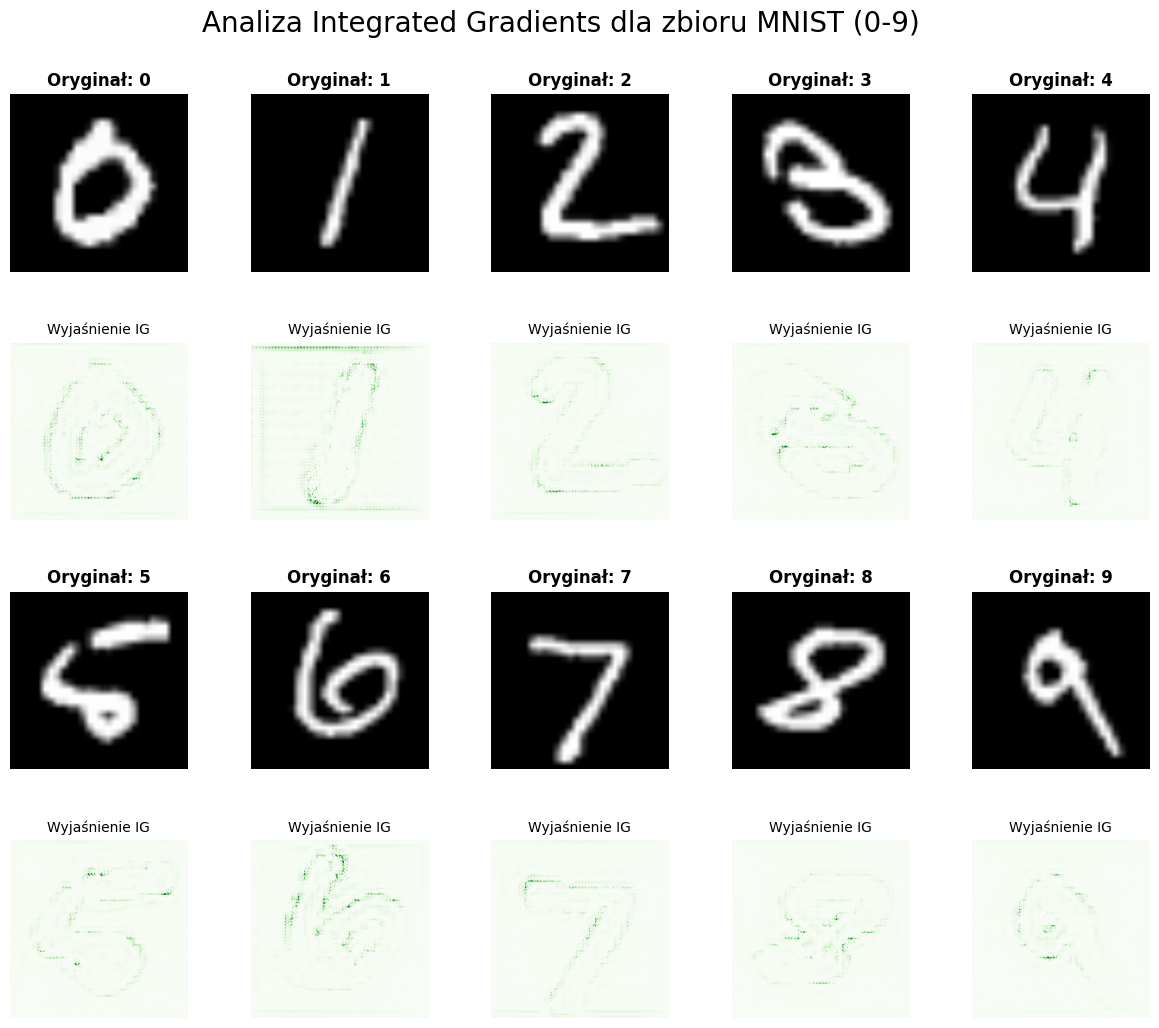

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision.utils import save_image

# 1. Konfiguracja
noised_data_path = Path("../data/MNIST/noised")
sigma_value = 0.01

examples = {}
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.2)
fig.suptitle("Analiza Integrated Gradients dla zbioru MNIST (0-9)", fontsize=20, y=0.95)

# 2. Zbieranie dokładnie 10 próbek z loadera
for images, labels in test_loader:
    for i in range(len(labels)):
        label = labels[i].item()
        if label not in examples:
            examples[label] = images[i].unsqueeze(0)

    if len(examples) == 10:
        break

# =========================================================
# ZAPIS DO FOLDERÓW (0-9)
# =========================================================
print(f"Tworzenie folderów i zapis zaszumionych obrazów w: {noised_data_path}")

# Najpierw upewniamy się, że foldery dla każdej klasy istnieją
for i in range(10):
    (noised_data_path / str(i)).mkdir(parents=True, exist_ok=True)

# Następnie szumimy i zapisujemy do odpowiednich podfolderów
for digit, clean_tensor in examples.items():
    noise = torch.randn_like(clean_tensor) * sigma_value
    noised_tensor = torch.clamp(clean_tensor + noise, 0.0, 1.0)

    # Ścieżka np: ../data/MNIST/noised/5/img_0.png
    file_path = noised_data_path / str(digit) / "img_0.png"

    save_image(noised_tensor.squeeze(0), file_path)
print("Zapis zakończony!")
# =========================================================

# 3. Wykres IG dla oryginalnych (czystych) danych - bez zmian
for digit in range(10):
    row_start = 0 if digit < 5 else 2
    col = digit % 5

    img_tensor = examples[digit].to(device)
    img_tensor.requires_grad = True

    attribution = ig.attribute(img_tensor, target=digit, n_steps=50)

    orig_np = img_tensor.squeeze().cpu().detach().numpy()
    attr_np = attribution.squeeze().cpu().detach().numpy()

    if attr_np.ndim == 3:
        attr_np = np.sum(attr_np, axis=0)
        orig_np = np.transpose(orig_np, (1, 2, 0))
        orig_np = (orig_np - orig_np.min()) / (orig_np.max() - orig_np.min())

    ax_orig = axes[row_start, col]
    ax_orig.imshow(orig_np, cmap="gray" if orig_np.ndim == 2 else None)
    ax_orig.set_title(f"Oryginał: {digit}", fontsize=12, fontweight="bold")
    ax_orig.axis("off")

    ax_attr = axes[row_start + 1, col]
    attr_np_pos = np.maximum(attr_np, 0)
    ax_attr.imshow(attr_np_pos, cmap="Greens")
    ax_attr.set_title(f"Wyjaśnienie IG", fontsize=10)
    ax_attr.axis("off")

plt.show()

## occulsion

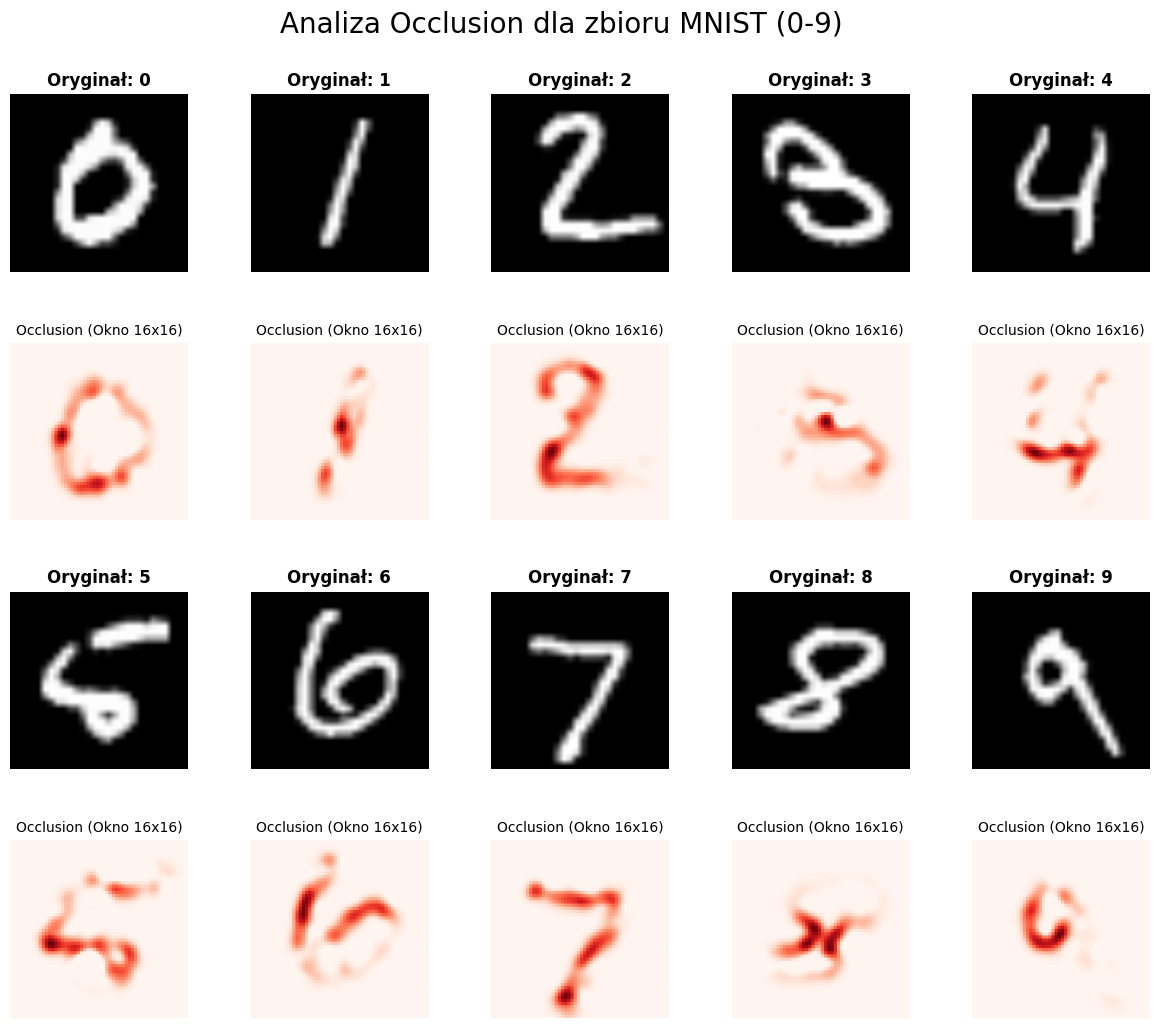

In [10]:
from captum.attr import Occlusion
import numpy as np
import matplotlib.pyplot as plt

# 1. Inicjalizacja Occlusion
# Occlusion operuje na całym modelu (jako czarna skrzynka), nie potrzebujemy wskazywać warstwy.
occ = Occlusion(model)
model.eval()

# Konfiguracja siatki 4 rzędy (2 dla cyfr 0-4, 2 dla cyfr 5-9)
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.2)
fig.suptitle("Analiza Occlusion dla zbioru MNIST (0-9)", fontsize=20, y=0.95)

for digit in range(10):
    row_start = 0 if digit < 5 else 2
    col = digit % 5

    img_tensor = examples[digit].to(device)

    # 2. Obliczanie atrybucji Occlusion
    # sliding_window_shapes: dla wejścia (1, 28, 28) robimy okienko (1, 4, 4)
    # strides: przesuwamy okienko co 2 piksele, żeby mapa była gładsza
    attr_occ = occ.attribute(
        img_tensor,
        target=digit,
        sliding_window_shapes=(1, 16, 16),
        strides=(1, 4, 4),
        perturbations_per_eval=256,
        baselines=-1,
    )

    # Przetwarzanie obrazu oryginalnego
    orig_np = img_tensor.squeeze().cpu().detach().numpy()
    if orig_np.ndim == 3:
        orig_np = np.transpose(orig_np, (1, 2, 0))
        orig_np = (orig_np - orig_np.min()) / (orig_np.max() - orig_np.min())

    # Przetwarzanie atrybucji Occlusion
    attr_occ_np = attr_occ.squeeze().cpu().detach().numpy()
    # Jeśli mamy wiele kanałów (np. RGB), sumujemy je dla czytelności
    if attr_occ_np.ndim == 3:
        attr_occ_np = np.sum(attr_occ_np, axis=0)

    # KLUCZOWE W OCCLUSION:
    # Dodatnie wartości oznaczają "gdy to zasłoniłem, model stracił pewność".
    # Bierzemy tylko je, wygaszając ujemne (np. tło, które po zasłonięciu nic nie zmienia).
    # attr_occ_pos = np.abs(np.minimum(attr_occ_np, 0))
    attr_occ_pos = np.maximum(attr_occ_np, 0)

    # Rząd 0 lub 2: Oryginały
    axes[row_start, col].imshow(orig_np, cmap="gray" if orig_np.ndim == 2 else None)
    axes[row_start, col].set_title(f"Oryginał: {digit}", fontsize=12, fontweight="bold")
    axes[row_start, col].axis("off")

    # Rząd 1 lub 3: Mapy Occlusion
    # Zmieniamy cmap na 'Reds', żeby odróżnić od Integrated Gradients (które masz w 'Greens')
    axes[row_start + 1, col].imshow(attr_occ_pos, cmap="Reds")
    axes[row_start + 1, col].set_title("Occlusion (Okno 16x16)", fontsize=10)
    axes[row_start + 1, col].axis("off")

plt.show()

## tworzenie zaszumionego gausem datasetu 

next step: zaszumic gausem zapisany dataset